In [1]:
import h5py as h5
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
h5_k5 = h5.File('../data/K562_histone_enhancer_marks.h5', 'r')
h5_k5_seq = h5.File('../data/K562_histone_appended_pe_encoding.h5', 'r')
h5_gm = h5.File('../data/GM12878_histone_enhancer_marks.h5', 'r')
h5_gm_seq = h5.File('../data/GM12878_histone_appended_pe_encoding.h5', 'r')
h5_k5.keys(), h5_k5_seq.keys()

(<KeysViewHDF5 ['GM12878', 'H3K27ac', 'H3K27me3', 'H3K36me3', 'H3K4me1', 'H3K4me3', 'H3K9me3', 'methylation']>,
 <KeysViewHDF5 ['H3K27ac', 'H3K27me3', 'H3K36me3', 'H3K4me1', 'H3K4me3', 'H3K9me3', 'distance', 'gene_id', 'pe_seqs']>)

In [3]:
# generate padding mask per sample (first dim) from h5_k5_seq 'pe_seqs' key
# ~(pe_seq.sum(-1).sum(-1) > 0).bool()
padding_mask = ~(h5_k5_seq['pe_seqs'][:].sum(-1).sum(-1) > 0).astype(bool)
padding_mask.shape

(18377, 61)

In [4]:
gene_info = pd.read_csv('../data/leave_chrom_out_crossvalidation_split_18377genes.csv')
gene_info.head()
ensid_to_chrom = dict(zip(gene_info['ENSID'], gene_info['chrom']))

In [28]:
def get_methylation_values(h5_file, h5_seq_file, padding_mask, ensid_to_chrom):
    all_methylation_values = []
    x_chromosome_meth = []
    num_samples = h5_file['methylation'].shape[0]
    
    for i in range(num_samples):
        meth = h5_file['methylation'][i]
        seq = h5_seq_file['pe_seqs'][i]
        mask = padding_mask[i]
        gene = h5_seq_file['gene_id'][i].decode('utf-8')
        chrom = ensid_to_chrom.get(gene, None)
        
        # filter out padding
        meth = meth[~mask]
        seq = seq[~mask]
        
        # mask positions where sequence is all zeros
        valid_positions = seq.sum(axis=-1) != 0
        meth = meth[valid_positions]
        
        if chrom == 'X':
            x_chromosome_meth.extend(meth[:, 0])
            continue
        all_methylation_values.extend(meth[:, 0])

    return all_methylation_values, x_chromosome_meth

# hist plot, two subplots, one for all methylation values, one for x chromosome only
meth_gm, x_meth_gm = get_methylation_values(h5_gm, h5_gm_seq, padding_mask, ensid_to_chrom)
meth_k5, x_meth_k5 = get_methylation_values(h5_k5, h5_k5_seq, padding_mask, ensid_to_chrom)


In [29]:
# sample 100000 values from each for better visualization

meth_gm = np.random.choice(meth_gm, 100000, replace=False)
x_meth_gm = np.random.choice(x_meth_gm, 100000, replace=False)
meth_k5 = np.random.choice(meth_k5, 100000, replace=False)
x_meth_k5 = np.random.choice(x_meth_k5, 100000, replace=False)

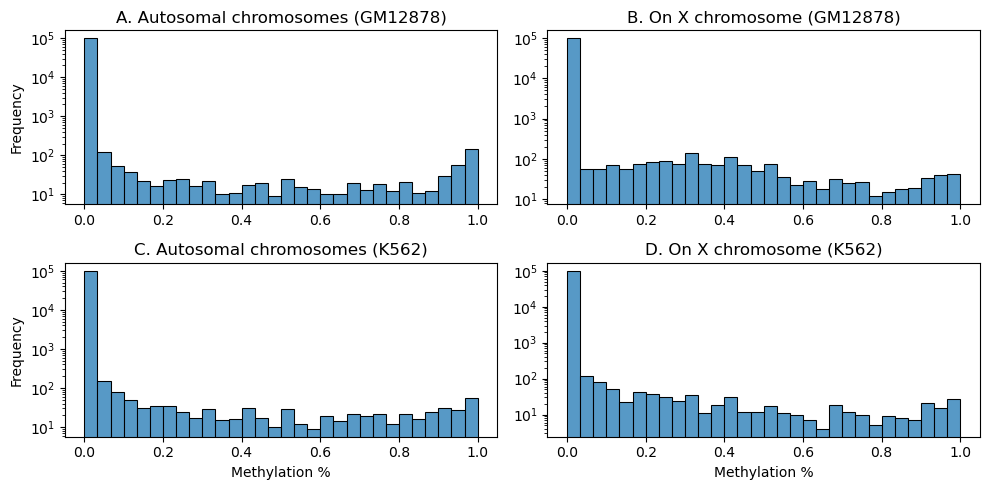

In [46]:
fig, ax = plt.subplots(2, 2, figsize=(10, 5))
sns.histplot(meth_gm, bins=30, kde=False, ax=ax[0, 0])
ax[0, 0].set_yscale('log')
ax[0, 0].set_title('A. Autosomal chromosomes (GM12878)')
#ax[0, 0].set_xlabel('Methylation %')
ax[0, 0].set_ylabel('Frequency')
sns.histplot(x_meth_gm, bins=30, kde=False, ax=ax[0, 1])
ax[0, 1].set_yscale('log')
ax[0, 1].set_title('B. On X chromosome (GM12878)')
#ax[0, 1].set_xlabel('Methylation %')
ax[0, 1].set_ylabel('')
sns.histplot(meth_k5, bins=30, kde=False, ax=ax[1, 0])
ax[1, 0].set_yscale('log')
ax[1, 0].set_title('C. Autosomal chromosomes (K562)')
ax[1, 0].set_xlabel('Methylation %')
ax[1, 0].set_ylabel('Frequency')
sns.histplot(x_meth_k5, bins=30, kde=False, ax=ax[1, 1])
ax[1, 1].set_yscale('log')
ax[1, 1].set_title('D. On X chromosome (K562)')
ax[1, 1].set_xlabel('Methylation %')
ax[1, 1].set_ylabel('')
plt.tight_layout()
plt.savefig('../images/methylation_distribution_enhancer.png', dpi=300)
plt.show()

In [31]:
h5_events = h5.File('../data/event_bp_histone_marks.h5', 'r')
h5_seq = h5.File('../data/event_encoding.h5', 'r')
h5_events['K562'].keys(), h5_seq.keys()

(<KeysViewHDF5 ['H3K27ac', 'H3K27me3', 'H3K36me3', 'H3K4me1', 'H3K4me3', 'H3K9me3', 'methylation']>,
 <KeysViewHDF5 ['H3K27ac_GM12878', 'H3K27ac_K562', 'H3K27me3_GM12878', 'H3K27me3_K562', 'H3K36me3_GM12878', 'H3K36me3_K562', 'H3K4me1_GM12878', 'H3K4me1_K562', 'H3K4me3_GM12878', 'H3K4me3_K562', 'H3K9me3_GM12878', 'H3K9me3_K562', 'event_id', 'event_seq', 'gene_id']>)

In [71]:
def get_event_methylation_values(h5_file, h5_seq_file, ensid_to_chrom, cell='K562'):
    all_methylation_values = []
    x_chromosome_meth = []
    num_samples = h5_file[cell]['methylation'].shape[0]
    x_genes = set()
    x_events = []

    for i in range(num_samples):
        meth = h5_file[cell]['methylation'][i]
        seq = h5_seq_file['event_seq'][i]
        gene = h5_seq_file['gene_id'][i].decode('utf-8')
        chrom = ensid_to_chrom.get(gene, None)
        
        #seq = seq[1, :] # only look at the central sequence
        #meth = meth[1, :] # only look at the central methylation
        
        # mask positions where sequence is all zeros
        valid_positions = seq.sum(axis=-1) != 0
        meth = meth[valid_positions]
        
        if chrom == 'X':
            x_genes.add(gene)
            x_events.append(i)
            x_chromosome_meth.extend(meth[:, 0])
            continue
        all_methylation_values.extend(meth[:, 0])

    print("Number of X chromosome genes:", len(x_genes), "\nNumber of X chromosome events:", len(x_events))
    return all_methylation_values, x_chromosome_meth

In [72]:
ev_meth_gm, ev_meth_x_gm = get_event_methylation_values(h5_events, h5_seq, ensid_to_chrom, cell='GM12878')
ev_meth_k5, ev_meth_x_k5 = get_event_methylation_values(h5_events, h5_seq, ensid_to_chrom, cell='K562')
print(len(ev_meth_gm), len(ev_meth_x_gm), len(ev_meth_k5), len(ev_meth_x_k5))

Number of X chromosome genes: 348 
Number of X chromosome events: 731
Number of X chromosome genes: 348 
Number of X chromosome events: 731
42425234 1231637 42425234 1231637


In [ ]:
# 42425234 1231637 42425234 1231637
#  3681694   01662  3681694  101662

In [69]:
# sample 100000 values from each for better visualization
if len(ev_meth_gm) > 100000:
    ev_meth_gm = np.random.choice(ev_meth_gm, 100000, replace=False)
if len(ev_meth_x_gm) > 100000:
    ev_meth_x_gm = np.random.choice(ev_meth_x_gm, 100000, replace=False)
if len(ev_meth_k5) > 100000:
    ev_meth_k5 = np.random.choice(ev_meth_k5, 100000, replace=False)
if len(ev_meth_x_k5) > 100000:
    ev_meth_x_k5 = np.random.choice(ev_meth_x_k5, 100000, replace=False)

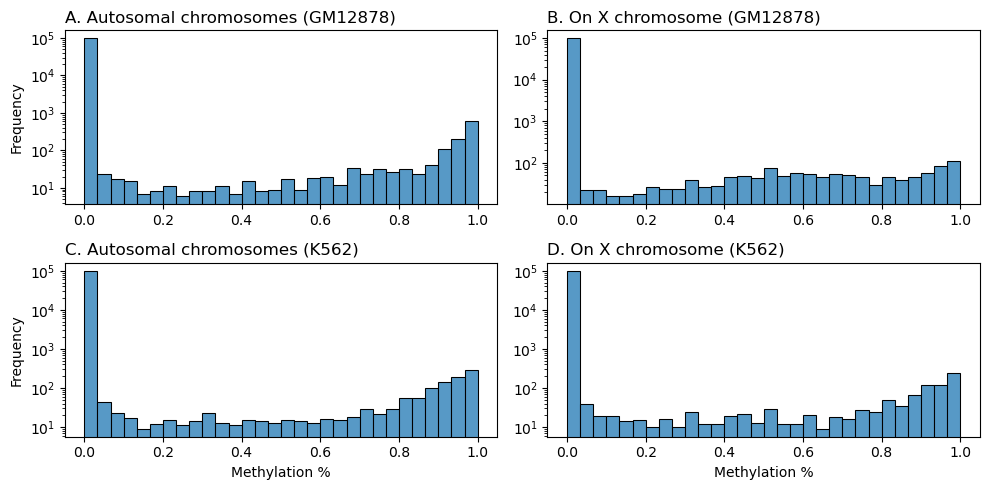

In [70]:
fig, ax = plt.subplots(2, 2, figsize=(10, 5))
sns.histplot(ev_meth_gm, bins=30, kde=False, ax=ax[0, 0])
ax[0, 0].set_yscale('log')
ax[0, 0].set_title('A. Autosomal chromosomes (GM12878)', loc='left')
#ax[0, 0].set_xlabel('Methylation %')
ax[0, 0].set_ylabel('Frequency')
sns.histplot(ev_meth_x_gm, bins=30, kde=False, ax=ax[0, 1])
ax[0, 1].set_yscale('log')
ax[0, 1].set_title('B. On X chromosome (GM12878)', loc='left')
#ax[0, 1].set_xlabel('Methylation %')
ax[0, 1].set_ylabel('')
sns.histplot(ev_meth_k5, bins=30, kde=False, ax=ax[1, 0])
ax[1, 0].set_yscale('log')
ax[1, 0].set_title('C. Autosomal chromosomes (K562)', loc='left')
ax[1, 0].set_xlabel('Methylation %')
ax[1, 0].set_ylabel('Frequency')
sns.histplot(ev_meth_x_k5, bins=30, kde=False, ax=ax[1, 1])
ax[1, 1].set_yscale('log')
ax[1, 1].set_title('D. On X chromosome (K562)', loc='left')
ax[1, 1].set_xlabel('Methylation %')
ax[1, 1].set_ylabel('')
plt.tight_layout()
plt.savefig('../images/methylation_distribution_events.png', dpi=300)
plt.show()